## 1. Imports & Configuration

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import os

DATA_PATH  = r"D:\Queens\DL-CISC 867-Deep Learning\DL Project\credit-card-fraud-detection\data\creditcard.csv"
OUTPUT_DIR = r"D:\Queens\DL-CISC 867-Deep Learning\DL Project\credit-card-fraud-detection\results"
SEED       = 42
TEST_SIZE  = 0.20
VAL_SIZE   = 0.10

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

In [6]:
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape:   {df.shape}")
print(f"Missing values:  {df.isnull().sum().sum()}")
print(f"\nClass distribution:")
print(df['Class'].value_counts())

fraud_pct = df['Class'].mean() * 100
print(f"\nFraud rate: {fraud_pct:.4f}%")

Dataset shape:   (284807, 31)
Missing values:  0

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


In [7]:
# Quick overview of the dataset
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 3. Exploratory Data Analysis (EDA)

### 3.1 Transaction Amount Distribution

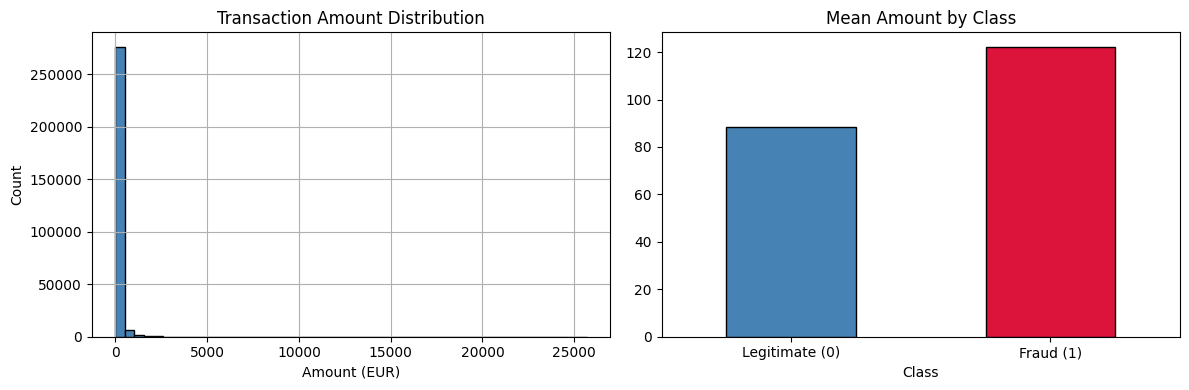

Plot saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Amount'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title("Transaction Amount Distribution")
axes[0].set_xlabel("Amount (EUR)")
axes[0].set_ylabel("Count")

df.groupby('Class')['Amount'].mean().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'crimson'], edgecolor='black')
axes[1].set_title("Mean Amount by Class")
axes[1].set_xticklabels(['Legitimate (0)', 'Fraud (1)'], rotation=0)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_amount_distribution.png", dpi=150)
plt.show()
print("Plot saved.")

### 3.2 Class Imbalance

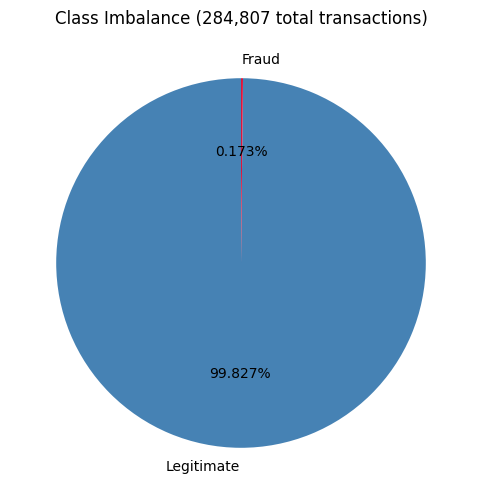

Legitimate: 284,315 | Fraud: 492


In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
counts = df['Class'].value_counts()

ax.pie(counts, labels=['Legitimate', 'Fraud'],
       autopct='%1.3f%%', colors=['steelblue', 'crimson'], startangle=90)
ax.set_title("Class Imbalance (284,807 total transactions)")

plt.savefig(f"{OUTPUT_DIR}/eda_class_imbalance.png", dpi=150)
plt.show()
print(f"Legitimate: {counts[0]:,} | Fraud: {counts[1]:,}")

### 3.3 Correlation Heatmap (Top Features vs Class)

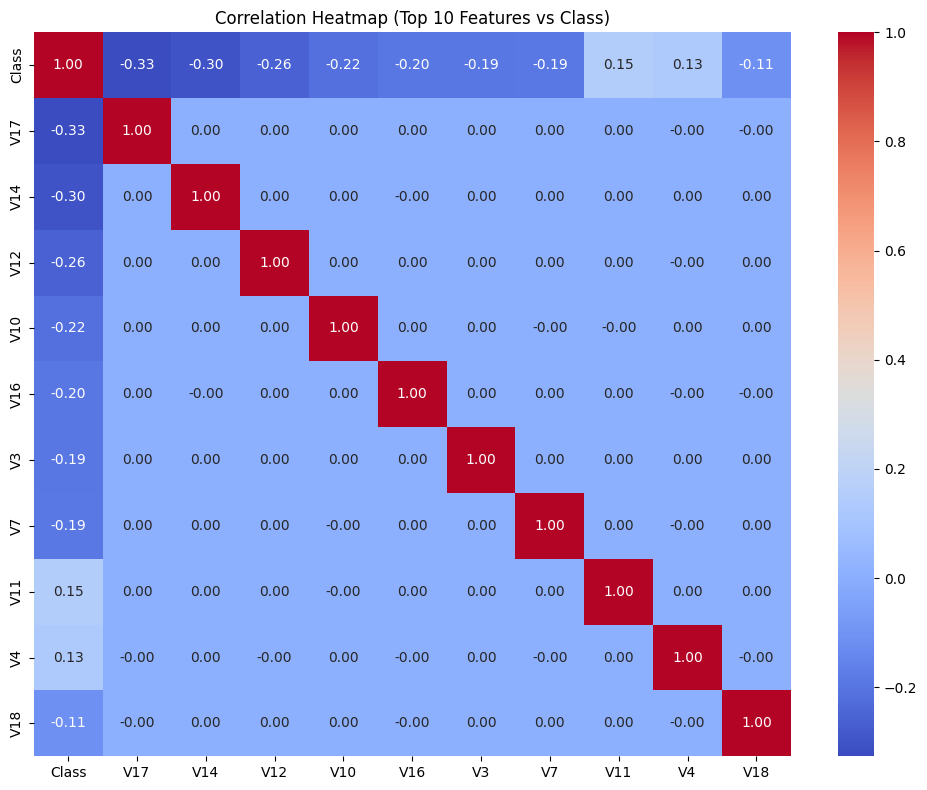

Top correlated features: ['Class', 'V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18']


In [10]:
top_corr = df.corr()['Class'].abs().nlargest(11).index.tolist()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[top_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title("Correlation Heatmap (Top 10 Features vs Class)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eda_correlation_heatmap.png", dpi=150)
plt.show()
print("Top correlated features:", top_corr)

## 4. Preprocessing

### 4.1 Feature Scaling
V1–V28 are already PCA-transformed. We only normalize `Time` and `Amount`.

In [11]:
scaler = StandardScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])

# Drop original unscaled columns
df.drop(columns=['Time', 'Amount'], inplace=True)

print("Scaling complete. New shape:", df.shape)
df[['Amount_scaled', 'Time_scaled']].describe()

Scaling complete. New shape: (284807, 31)


,Amount_scaled,Time_scaled
count,2.848070e+05,2.848070e+05
mean,-3.672378e-17,-5.109395e-17
std,1.000002e+00,1.000002e+00
min,-3.532294e-01,-1.996583e+00
25%,-3.308401e-01,-8.552120e-01
50%,-2.652715e-01,-2.131453e-01
75%,-4.471707e-02,9.372174e-01
max,1.023622e+02,1.642058e+00


### 4.2 Features & Target Split

In [12]:
X = df.drop(columns=['Class'])
y = df['Class']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")

Features shape: (284807, 30)
Target shape:   (284807,)


### 4.3 Train / Validation / Test Split (70 / 10 / 20)

In [13]:
# First split: train+val vs test (80/20)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y)

# Second split: train vs val (87.5/12.5 of 80% = 70/10 overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=SEED, stratify=y_temp)

print(f"Train size: {len(X_train):,}  ({y_train.mean()*100:.3f}% fraud)")
print(f"Val size:   {len(X_val):,}   ({y_val.mean()*100:.3f}% fraud)")
print(f"Test size:  {len(X_test):,}  ({y_test.mean()*100:.3f}% fraud)")

Train size: 199,364  (0.173% fraud)
Val size:   28,481   (0.172% fraud)
Test size:  56,962  (0.172% fraud)


### 4.4 SMOTE — Applied on Training Set ONLY

In [14]:
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE → Train: {len(X_train):,} | Fraud: {y_train.sum()}")
print(f"After SMOTE  → Train: {len(X_train_sm):,} | Fraud: {y_train_sm.sum():,}")

Before SMOTE → Train: 199,364 | Fraud: 345
After SMOTE  → Train: 398,038 | Fraud: 199,019


## 5. Save Preprocessed Splits

In [15]:
# Original splits (for XGBoost which handles imbalance natively)
np.save(f"{OUTPUT_DIR}/X_train.npy",    X_train.values)
np.save(f"{OUTPUT_DIR}/X_val.npy",      X_val.values)
np.save(f"{OUTPUT_DIR}/X_test.npy",     X_test.values)
np.save(f"{OUTPUT_DIR}/y_train.npy",    y_train.values)
np.save(f"{OUTPUT_DIR}/y_val.npy",      y_val.values)
np.save(f"{OUTPUT_DIR}/y_test.npy",     y_test.values)

# SMOTE-balanced splits (for LR, RF, MLP)
np.save(f"{OUTPUT_DIR}/X_train_sm.npy", X_train_sm)
np.save(f"{OUTPUT_DIR}/y_train_sm.npy", y_train_sm)

print("All splits saved to results/ folder:")
for f in os.listdir(OUTPUT_DIR):
    if f.endswith('.npy'):
        size = os.path.getsize(f"{OUTPUT_DIR}/{f}")/1e6
        print(f"  {f:<25} {size:.1f} MB")

All splits saved to results/ folder:
  X_test.npy                13.7 MB
  X_train.npy               47.8 MB
  X_train_sm.npy            95.5 MB
  X_val.npy                 6.8 MB
  y_test.npy                0.5 MB
  y_train.npy               1.6 MB
  y_train_sm.npy            3.2 MB
  y_val.npy                 0.2 MB
